# Raport z zadań z listy 2

## załadowanie zbiorów danych
Do wykonania zadań klasyfikacyjnych na ocenę 3.0 oraz na ocenę 3.5 używam zbioru Telco Customer Churn (Target Churn). Do zadań regresyjnych na ocenę 4.0, 4.5 oraz 5.0 używam zbioru Diamonds (target Price)

In [125]:
from file_operations import load_diamonds_data, load_telco_data, split_diamonds_data, split_telco_data
import pandas as pd

telco_df = load_telco_data()
telco_train_df, telco_test_df = split_telco_data(telco_df)

diamonds_df = load_diamonds_data()
diamonds_train_df, diamonds_test_df = split_diamonds_data(diamonds_df)

## Zadanie 3.0

W tej czesci buduje model klasyfikacyjny oparty o drzewo decyzyjne dla zbioru `Telco Customer Churn`. Najpierw przygotowuje dane, potem ucze model, a na koncu oceniam go metrykami odpowiednimi dla niezbalansowanej klasyfikacji.


In [126]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier

from plots import plot_classification_metrics
from preprocessing import prepare_telco_classification_data


# Prosta klasa zgodna ze stylem fit(X, y) i predict(X).
class TreeDecision:
    def __init__(self, max_depth=5, random_state=42):
        self.model = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
        self.columns = None

    def fit(self, X, y):
        # Kodujemy zmienne kategorialne do postaci 0/1.
        X_encoded = pd.get_dummies(X)
        self.columns = X_encoded.columns.tolist()
        self.model.fit(X_encoded, y)
        return self

    def predict(self, X):
        # W tescie ustawiamy te same kolumny co na treningu.
        X_encoded = pd.get_dummies(X)
        X_encoded = X_encoded.reindex(columns=self.columns, fill_value=0)
        return self.model.predict(X_encoded)


# Przygotowanie danych: usuniecie targetu i ID oraz uzupelnienie brakow.
X_train, y_train, X_test, y_test = prepare_telco_classification_data(
    telco_train_df,
    telco_test_df,
)

# Uczenie modelu drzewa decyzyjnego.
model = TreeDecision(max_depth=5)
model.fit(X_train, y_train)

# Predykcja na zbiorze testowym.
y_pred = model.predict(X_test)


,metric,value
0,accuracy,0.7984
1,precision,0.6347
2,recall,0.5668
3,f1,0.5989


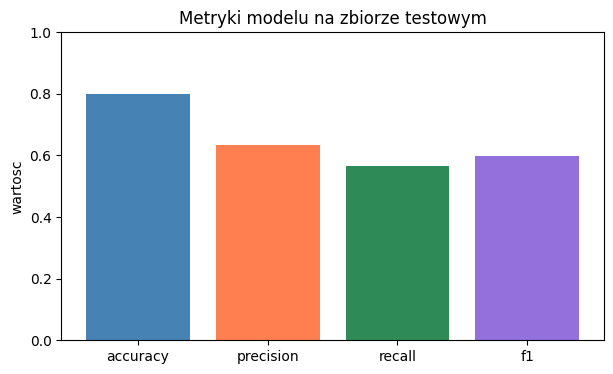

In [127]:
# Podstawowe metryki klasyfikacji dla klasy Churn = Yes.
metrics_df = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1"],
        "value": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, pos_label="Yes"),
            recall_score(y_test, y_pred, pos_label="Yes"),
            f1_score(y_test, y_pred, pos_label="Yes"),
        ],
    }
)

display(metrics_df.round(4))

plot_classification_metrics(metrics_df)



**Opis tabeli metryk i wykresu metryk**

- Model drzewa decyzyjnego osiagnal `accuracy` na poziomie okolo `0.80`, co jest wynikiem poprawnym, ale w tym zadaniu sama trafnosc nie wystarcza do rzetelnej oceny jakosci modelu. Zbior `Churn` jest niezbalansowany, dlatego wieksze znaczenie maja metryki `precision`, `recall` oraz `F1` dla klasy `Yes`, czyli klientow rezygnujacych z uslug.
- `Precision` na poziomie okolo `0.63` oznacza, ze przewidywania odejscia klienta sa w 63% poprawne, ale model nadal generuje część "fałszywych alarmów".
- `Recall` na poziomie okolo `0.57` pokazuje natomiast, ze model wykrywa tylko 57% rzeczywistych odejsc, wiec pomija istotna grupe klientow zagrozonych rezygnacja.
- `F1 score` na poziomie okolo `0.60` potwierdza, ze model osiagnal umiarkowana rownowage pomiedzy precyzja i czuloscia.
- Wykres slupkowy metryk dobrze pokazuje te relacje: `accuracy` jest najwyzsza, ale bardziej wymagajace metryki dla klasy mniejszosciowej sa wyraznie nizsze. Oznacza to, ze model radzi sobie przyzwoicie ogolnie, ale slabiej w wykrywaniu klientow odchodzacych.


Macierz pomylek:
[[913 122]
 [162 212]]


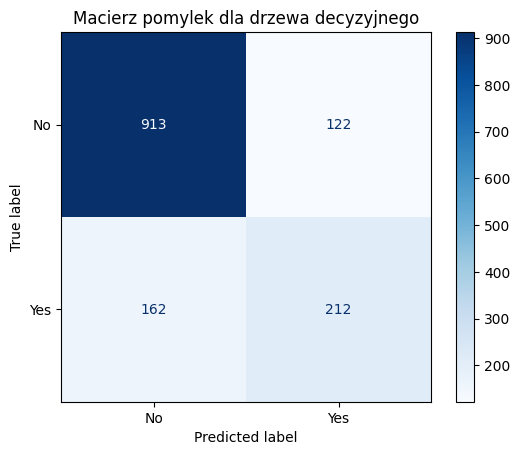

In [128]:
from plots import plot_confusion_matrix


# Macierz pomylek pokazuje liczbe poprawnych i blednych decyzji modelu.
print("Macierz pomylek:")
print(confusion_matrix(y_test, y_pred, labels=["No", "Yes"]))

# Rysowanie macierzy pomylek przenosimy do helpera, aby raport zostal czytelny.
plot_confusion_matrix(y_test, y_pred)


**Opis macierzy pomylek**
Model 913 razy przewidział poprawanie, że klient nie odejdzie, 212 razy, że odejdzie. w 122 przypadkach klient nie odszedł, ale model przewidział, że odejdzie, a w 162 przypadkach klient odszedł a model przewidział, że nie odejdzie.
Przewaga lewego gornego pola nad prawym dolnym od razu pokazuje, ze model jest bardziej pewny dla klasy `No` niz dla klasy `Yes`.

Najwiecej bledow pojawia sie wtedy, gdy klient rzeczywiscie odchodzi, ale model przewiduje `No`, czyli pozostanie. To wlasnie ta grupa bledow obniza `recall` dla klasy `Yes`. Macierz potwierdza wiec to, co bylo widoczne juz w tabeli metryk.


## Zadanie 3.5

W tej czesci przechodze od samej skutecznosci modelu do jego interpretacji. Pokazuje reguly drzewa, waznosc cech oraz reczne obliczenia entropii i information gain, aby sprawdzic, czy decyzje modelu maja sens.


Reguly drzewa decyzyjnego:
|--- Contract_Month-to-month <= 0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- OnlineSecurity_No <= 0.50
|   |   |   |--- Contract_One year <= 0.50
|   |   |   |   |--- OnlineBackup_No <= 0.50
|   |   |   |   |   |--- class: No
|   |   |   |   |--- OnlineBackup_No >  0.50
|   |   |   |   |   |--- class: No
|   |   |   |--- Contract_One year >  0.50
|   |   |   |   |--- MonthlyCharges <= 72.17
|   |   |   |   |   |--- class: No
|   |   |   |   |--- MonthlyCharges >  72.17
|   |   |   |   |   |--- class: No
|   |   |--- OnlineSecurity_No >  0.50
|   |   |   |--- Contract_Two year <= 0.50
|   |   |   |   |--- PaymentMethod_Mailed check <= 0.50
|   |   |   |   |   |--- class: No
|   |   |   |   |--- PaymentMethod_Mailed check >  0.50
|   |   |   |   |   |--- class: No
|   |   |   |--- Contract_Two year >  0.50
|   |   |   |   |--- MonthlyCharges <= 54.47
|   |   |   |   |   |--- class: No
|   |   |   |   |--- MonthlyCharges >  54.47
|   |   |   |   |   |--- c

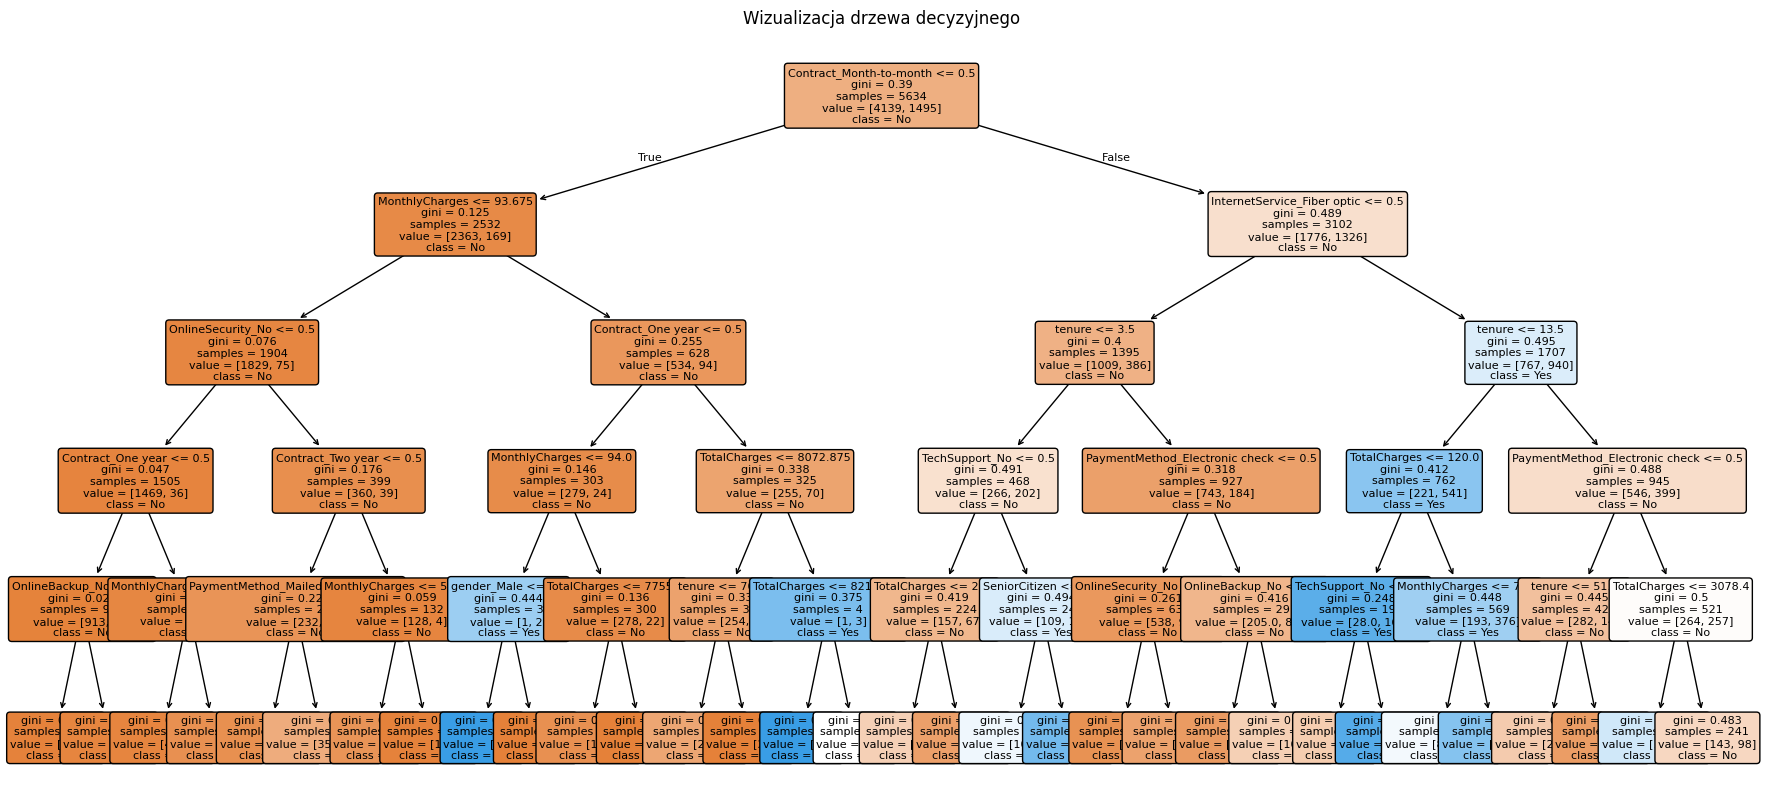

In [129]:
import pandas as pd
from math import log2
from sklearn.tree import export_text

from helpers import get_thresholds_from_tree
from plots import plot_decision_tree
from preprocessing import prepare_telco_classification_data


# Przygotowanie danych jak w zadaniu 3.0.
X_train, y_train, X_test, y_test = prepare_telco_classification_data(
    telco_train_df,
    telco_test_df,
)

# Trenujemy plytkie drzewo, zeby latwo bylo je narysowac i opisac.
interpretation_model = TreeDecision(max_depth=5)
interpretation_model.fit(X_train, y_train)

# Tekstowy zapis regul if/else.
print("Reguly drzewa decyzyjnego:")
print(export_text(interpretation_model.model, feature_names=interpretation_model.columns))

# Sama wizualizacja trafia do helpera, bo nie jest kluczowa dla logiki zadania.
plot_decision_tree(interpretation_model.model, interpretation_model.columns)

# Kodujemy trening dokladnie tak jak widzi go model.
encoded_train_df = pd.get_dummies(X_train)
encoded_train_df = encoded_train_df.reindex(columns=interpretation_model.columns, fill_value=0)


**Opis wizualizacji drzewa i regu? decyzyjnych**

Warunki wybrane przez algorytm maja sens dziedzinowy. Drzewo juz w gornych poziomach korzysta z cech takich jak `Contract_Month-to-month`, `MonthlyCharges`, `tenure`, `InternetService_Fiber optic`, `OnlineSecurity_No` oraz `TechSupport_No`. Taki wybor jest logiczny, poniewaz klient bez dlugoterminowej umowy jest mniej zwiazany z operatorem, wysoka miesieczna oplata moze zwiekszac sklonnosc do odejscia, a krotki staz oznacza mniejsza lojalnosc. Dodatkowo brak uslug takich jak wsparcie techniczne lub bezpieczenstwo online moze oznaczac slabsze przywiazanie klienta do oferty firmy.

Wizualizacja drzewa pomaga zobaczyc to samo w bardziej intuicyjnej formie. Najwyzsze poziomy drzewa odpowiadaja za najwazniejsze decyzje modelu, dlatego fakt, ze juz na poczatku pojawia sie `Contract_Month-to-month`, potwierdza duze znaczenie tej cechy dla przewidywania `Churn`. 

Dla max_depth = 5 widzimy, że reguł tych jest bardzo dużo w porównaniu z prostym systemem decyzyjnym z listy pierwszej (acccuracy wówczas wynioslo okolo 73% a tutaj 80%)


Cechy z dodatnia waznoscia, czyli realnie wykorzystane przez drzewo:


,feature,importance
0,Contract_Month-to-month,0.513973
1,InternetService_Fiber optic,0.163262
2,tenure,0.156717
3,TotalCharges,0.036499
4,MonthlyCharges,0.035922
5,PaymentMethod_Electronic check,0.027931
6,TechSupport_No,0.026824
7,Contract_One year,0.009218
8,OnlineBackup_No,0.009198
9,OnlineSecurity_No,0.008620


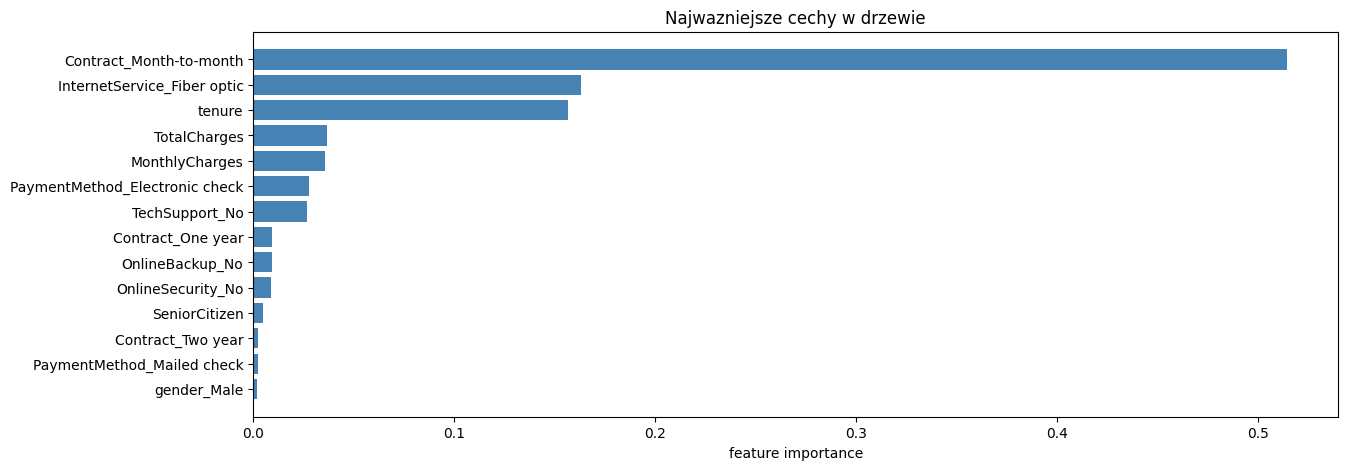

In [130]:
from plots import plot_feature_importance


# Pelna tabela wszystkich cech po kodowaniu.
all_importance_df = pd.DataFrame(
    {
        "feature": interpretation_model.columns,
        "importance": interpretation_model.model.feature_importances_,
    }
)
all_importance_df = all_importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

# Interesuja nas tez cechy realnie wykorzystane przez drzewo.
used_importance_df = all_importance_df[all_importance_df["importance"] > 0].copy()
used_importance_df = used_importance_df.reset_index(drop=True)

print("Cechy z dodatnia waznoscia, czyli realnie wykorzystane przez drzewo:")
display(used_importance_df.round(6))

# Wykres waznosci cech nie zmienia rozwiazania, wiec korzystamy z helpera.
top_features_df = used_importance_df.head(14).copy()
plot_feature_importance(top_features_df)


**Opis tabeli i wykresu waznosci cech**

Najwazniejsza cecha wedlug `feature_importances_` to `Contract_Month-to-month`, a duze znaczenie maja takze `InternetService_Fiber optic`, `tenure`, `TotalCharges` oraz `MonthlyCharges`. Pokrywa sie to z intuicja z Listy 1. Juz wtedy bylo widac, ze najwieksze ryzyko rezygnacji dotyczy klientow z umowa miesieczna, krotszym czasem korzystania z uslug oraz wyzszymi kosztami.

Wykres waznosci cech dobrze porzadkuje te obserwacje. Slupki dla kilku pierwszych zmiennych sa wyraznie wyzsze od pozostalych, co pokazuje, ze model nie korzysta ze wszystkich informacji rownomiernie, tylko opiera decyzje glownie na waskiej grupie najsilniejszych predyktorow.


,feature,tree_threshold,feature_importance,manual_information_gain
0,Contract_Month-to-month,0.5,0.513973,0.133580
1,gender_Male,0.5,0.001889,0.000004


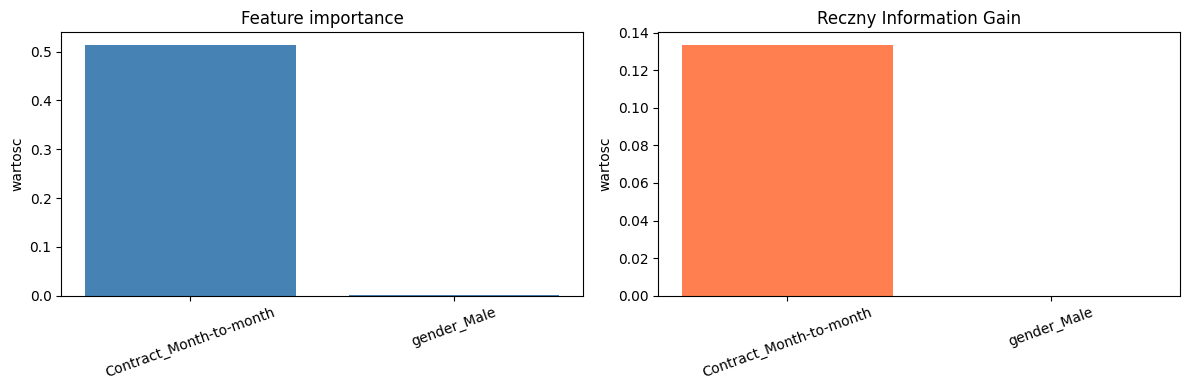

In [131]:
from plots import plot_information_gain_comparison


feature_thresholds = get_thresholds_from_tree(interpretation_model.model, interpretation_model.columns)

most_important_feature = used_importance_df.iloc[0]["feature"]
least_important_feature = used_importance_df.iloc[-1]["feature"]

most_important_threshold = feature_thresholds[most_important_feature][0]
least_important_threshold = feature_thresholds[least_important_feature][0]

# Reczne liczenie entropii zostaje w raporcie, bo jest wprost wymagane w poleceniu.
def entropy_manual(y):
    probabilities = y.value_counts(normalize=True)
    entropy_value = 0
    for probability in probabilities:
        if probability > 0:
            entropy_value += -probability * log2(probability)
    return entropy_value


# Reczne liczenie information gain dla pojedynczego podzialu.
def information_gain_manual(X, y, feature_name, threshold):
    # liczymy entropie na poczatku
    parent_entropy = entropy_manual(y)

    #dzielimy zbiór na dwie grupy
    left_mask = X[feature_name] <= threshold
    right_mask = X[feature_name] > threshold

    # wyciągamy odpowiedzi tylko dla tych podzielonych grup
    y_left = y[left_mask]
    y_right = y[right_mask]

    if len(y_left) == 0 or len(y_right) == 0:
        return 0.0

    #obliczamy wagi grup
    left_weight = len(y_left) / len(y)
    right_weight = len(y_right) / len(y)

    #entropia dziecka
    children_entropy = (
        left_weight * entropy_manual(y_left)
        + right_weight * entropy_manual(y_right)
    )

    return parent_entropy - children_entropy


most_important_gain = information_gain_manual(
    encoded_train_df,
    y_train,
    most_important_feature,
    most_important_threshold,
)

least_important_gain = information_gain_manual(
    encoded_train_df,
    y_train,
    least_important_feature,
    least_important_threshold,
)

comparison_df = pd.DataFrame(
    {
        "feature": [most_important_feature, least_important_feature],
        "tree_threshold": [most_important_threshold, least_important_threshold],
        "feature_importance": [
            used_importance_df.iloc[0]["importance"],
            used_importance_df.iloc[-1]["importance"],
        ],
        "manual_information_gain": [most_important_gain, least_important_gain],
    }
)

display(comparison_df.round(6))

# Wykres jest tylko wizualnym podsumowaniem recznych obliczen.
comparison_plot_df = comparison_df.copy()
comparison_plot_df["feature_importance"] = comparison_plot_df["feature_importance"].astype(float)
comparison_plot_df["manual_information_gain"] = comparison_plot_df["manual_information_gain"].astype(float)
plot_information_gain_comparison(comparison_plot_df)


**Opis porownania `feature importance` i `information gain`**

Wsrod cech wykorzystanych przez model najwieksza waznosc ma `Contract_Month-to-month`, a najmniejsza dodatnia waznosc ma `gender_Male`. To rozroznienie jest wazne, bo wiele cech po kodowaniu ma importance rowne `0`, czyli w ogole nie zostaly wykorzystane przez drzewo.

Wykres porownujacy `feature importance` i recznie policzony `information gain` pokazuje zgodny kierunek wnioskowania. Cecha uznana przez drzewo za bardzo wazna ma tez wysoki zysk informacyjny, a cecha slaba daje zysk bliski zeru. Dzieki temu latwiej uzasadnic, ze model nie tylko dziala, ale tez podejmuje decyzje w logiczny sposob.


In [132]:
# Krotkie podsumowanie liczbowe dla raportu.
print("Entropia calego zbioru treningowego:", round(entropy_manual(y_train), 6))
print("Najwazniejsza cecha:", most_important_feature)
print("Prog podzialu:", round(most_important_threshold, 6))
print("Information Gain:", round(most_important_gain, 6))
print()
print("Cecha o najmniejszej dodatniej waznosci:", least_important_feature)
print("Prog podzialu:", round(least_important_threshold, 6))
print("Information Gain:", round(least_important_gain, 6))


Entropia calego zbioru treningowego: 0.834717
Najwazniejsza cecha: Contract_Month-to-month
Prog podzialu: 0.5
Information Gain: 0.13358

Cecha o najmniejszej dodatniej waznosci: gender_Male
Prog podzialu: 0.5
Information Gain: 4e-06


**Opis recznych obliczen entropii i information gain**

Reczne obliczenia wykonane funkcjami `entropy_manual` oraz `information_gain_manual` potwierdzaja wyniki modelu. Dla cechy `Contract_Month-to-month` zysk informacyjny jest wyraznie wysoki, natomiast dla cechy `gender_Male` jest praktycznie zerowy. Oznacza to, ze podzial po typie umowy rzeczywiscie mocno zmniejsza niepewnosc co do klasy `Churn`, a podzial po plci wnosi bardzo malo informacji.

Wypisane podsumowanie liczbowe pod wykresem jest tu istotne, bo pokazuje konkretne wartosci entropii oraz `information gain`. Dzieki temu interpretacja nie opiera sie tylko na intuicji z wykresu, ale rowniez na recznie policzonych liczbach.


## Zadanie 4.0

W tej czesci porownuje trzy sposoby uczenia regresji liniowej na zbiorze `Diamonds`: rozwiazanie analityczne, gradient descent oraz model biblioteczny z `scikit-learn`. Wszystkie modele ucza sie na tych samych danych, dzieki czemu mozna uczciwie porownac ich bledy i wagi.


,model,mse,mae
0,normal equation,1.288705e+06,737.1514
1,gradient descent,1.292235e+06,748.4596
2,sklearn LinearRegression,1.288705e+06,737.1514


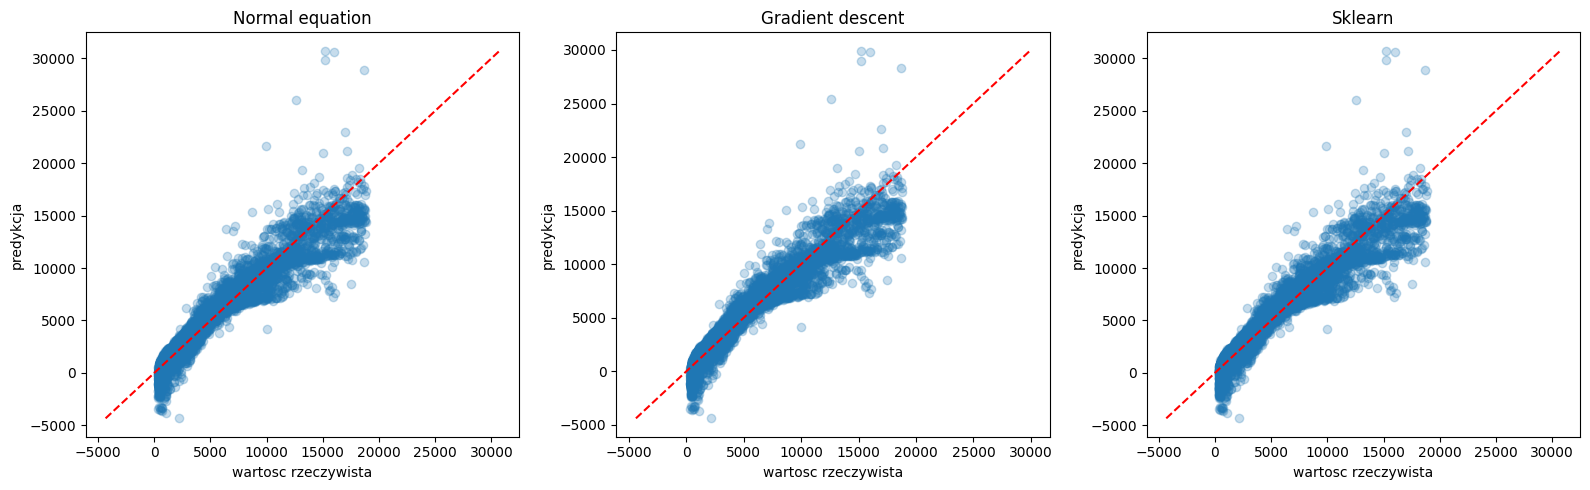

In [133]:
import importlib
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from helpers import add_intercept, standardize_train_test
from plots import plot_loss_history, plot_regression_predictions

import preprocessing
importlib.reload(preprocessing)
from preprocessing import prepare_diamonds_regression_data


class LinearRegressionNormalEquation:
    def __init__(self):
        self.weights = None

    def fit(self, X, y):
        # Dodajemy kolumnę jedynek. Bez tego linia regresji musiałaby przechodzić przez środek układu współrzędnych (0,0)
        X_with_intercept = add_intercept(X)
        
        # Obliczamy wagi korzystając z macierzy pseudoodwrotnej Moore'a-Penrose'a.
        self.weights = np.linalg.pinv(X_with_intercept) @ y
        return self

    def predict(self, X):
        # Aby przewidzieć wynik również musimy dodać kolumnę jedynek.
        X_with_intercept = add_intercept(X)
        # Wynik to iloczyn macierzowy cech i wyliczonych wag.
        return X_with_intercept @ self.weights
    
    
class LinearRegressionGradientDescent:
    def __init__(self, learning_rate=0.1, epochs=5000):
        self.learning_rate = learning_rate  # długośc kroku schodzenia
        self.epochs = epochs  # Liczba kroków
        self.weights = None 
        self.loss_history = []  # Historia błędu MSE, aby sprawdzić czy model się zbiega

    def fit(self, X, y):
        # Przygotowanie danych i zainicjowanie wag zerami.
        X_with_intercept = add_intercept(X)
        self.weights = np.zeros(X_with_intercept.shape[1])

        for _ in range(self.epochs):
            # Obliczamy aktualne przewidywania modelu
            y_pred = X_with_intercept @ self.weights
            
            # Obliczamy błąd
            error = y_pred - y
            
            # Obliczamy gradient gdzie (2/n) * X^T * error to pochodna funkcji MSE.
            gradient = (2 / len(X_with_intercept)) * (X_with_intercept.T @ error)
            
            # Aktualizacja wag0 robimy mały krok w kierunku przeciwnym do gradientu.
            self.weights = self.weights - self.learning_rate * gradient
            
            # Zapisujemy aktualny błąd średniokwadratowy do historii.
            mse_value = np.mean(error ** 2)
            self.loss_history.append(mse_value)

        return self

    def predict(self, X):
        # Przewidywanie polega na przemnożeniu danych wejściowych przez wyuczone wagi.
        X_with_intercept = add_intercept(X)
        return X_with_intercept @ self.weights


# Przygotowanie danych regresyjnych dla zbioru Diamonds.
X_train_raw, y_train, X_test_raw, y_test = prepare_diamonds_regression_data(
    diamonds_train_df,
    diamonds_test_df,
)

# Zmienne kategorialne kodujemy do postaci 0/1.
X_train_encoded = pd.get_dummies(X_train_raw)
X_test_encoded = pd.get_dummies(X_test_raw)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Wszystkie trzy modele ucza sie na tej samej, recznie standaryzowanej macierzy.
X_train_array = X_train_encoded.to_numpy(dtype=float)
X_test_array = X_test_encoded.to_numpy(dtype=float)
# przeskalowanie 
X_train_scaled, X_test_scaled = standardize_train_test(X_train_array, X_test_array)
y_train_array = y_train.to_numpy(dtype=float)
y_test_array = y_test.to_numpy(dtype=float)

normal_model = LinearRegressionNormalEquation()
gradient_model = LinearRegressionGradientDescent(learning_rate=0.01, epochs=5000)
sklearn_model = LinearRegression()

normal_model.fit(X_train_scaled, y_train_array)
gradient_model.fit(X_train_scaled, y_train_array)
sklearn_model.fit(X_train_scaled, y_train_array)

normal_predictions = normal_model.predict(X_test_scaled)
gradient_predictions = gradient_model.predict(X_test_scaled)
sklearn_predictions = sklearn_model.predict(X_test_scaled)

# Tabela porownujaca bledy MSE i MAE.
results_df = pd.DataFrame(
    {
        "model": ["normal equation", "gradient descent", "sklearn LinearRegression"],
        "mse": [
            mean_squared_error(y_test_array, normal_predictions),
            mean_squared_error(y_test_array, gradient_predictions),
            mean_squared_error(y_test_array, sklearn_predictions),
        ],
        "mae": [
            mean_absolute_error(y_test_array, normal_predictions),
            mean_absolute_error(y_test_array, gradient_predictions),
            mean_absolute_error(y_test_array, sklearn_predictions),
        ],
    }
)

display(results_df.round(4))

# Wykresy pomocnicze przenosimy do osobnego pliku, aby w raporcie zostala logika modelu.
predictions_list = [
    ("Normal equation", normal_predictions),
    ("Gradient descent", gradient_predictions),
    ("Sklearn", sklearn_predictions),
]
plot_regression_predictions(y_test_array, predictions_list)


**Opis tabeli metryk regresji i wykresu `wartosc rzeczywista vs predykcja`**

Wszystkie trzy podejscia daly bardzo zblizone wyniki na zbiorze testowym, co potwierdza poprawna implementacje regresji liniowej metoda analityczna oraz metoda gradient descent. Bledy `MSE` i `MAE` dla rozwiazania opartego o macierz pseudoodwrotna, gradient descent oraz modelu `LinearRegression` ze `scikit-learn` sa praktycznie takie same, wiec mozna uznac, ze wszystkie trzy modele ucza sie tej samej zaleznosci.



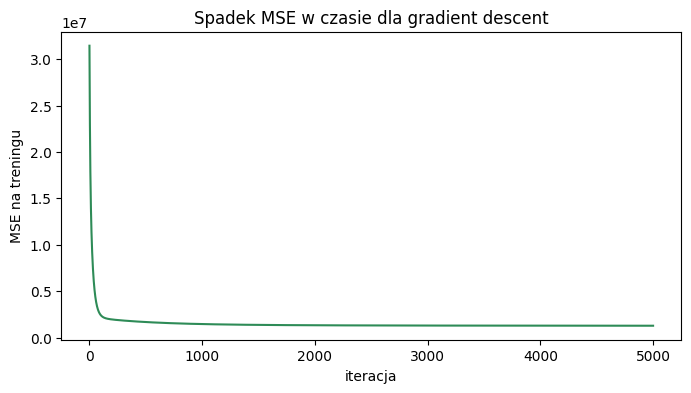

In [134]:
plot_loss_history(gradient_model.loss_history)


**Opis wykresu spadku MSE dla gradient descent**

Wykres `Spadek MSE w czasie dla gradient descent` pokazuje, czy metoda iteracyjna rzeczywiscie uczy sie poprawnie. Malejacy blad w kolejnych iteracjach oznacza, ze algorytm zbiega do minimum funkcji kosztu, a brak skokow i rozbiegania sugeruje, ze dobrany `learning rate` jest odpowiedni.


In [135]:
# Wypisujemy wektory wag dla wszystkich trzech podejsc.
feature_names = ["intercept"] + X_train_encoded.columns.tolist()
weights_df = pd.DataFrame(
    {
        "feature": feature_names,
        "normal_equation": normal_model.weights,
        "gradient_descent": gradient_model.weights,
        "sklearn": np.concatenate([[sklearn_model.intercept_], sklearn_model.coef_]),
    }
)

display(weights_df.round(6))

# Dodatkowo sprawdzamy, jak bardzo roznia sie wagi miedzy metodami.
weight_comparison_df = pd.DataFrame(
    {
        "comparison": ["normal vs sklearn", "gradient vs sklearn"],
        "max_abs_difference": [
            np.max(np.abs(normal_model.weights[1:] - sklearn_model.coef_)),
            np.max(np.abs(gradient_model.weights[1:] - sklearn_model.coef_)),
        ],
        "intercept_difference": [
            abs(normal_model.weights[0] - sklearn_model.intercept_),
            abs(gradient_model.weights[0] - sklearn_model.intercept_),
        ],
    }
)

display(weight_comparison_df.round(10))


,feature,normal_equation,gradient_descent,sklearn
0,intercept,3939.490707,3939.490707,3939.490707
1,carat,5339.601689,5049.285128,5339.601689
2,depth,-92.964717,-55.196702,-92.964717
3,table,-59.299400,-58.943587,-59.299400
4,x,-1129.191378,-531.441848,-1129.191378
5,y,-4.048849,-139.034545,-4.048849
6,z,-25.818033,-204.322056,-25.818033
7,cut_Fair,-126.445756,-129.387201,-126.445756
8,cut_Good,-44.432402,-44.671614,-44.432402
9,cut_Ideal,54.910804,55.262512,54.910804


,comparison,max_abs_difference,intercept_difference
0,normal vs sklearn,0.00000,0.0
1,gradient vs sklearn,597.74953,0.0


**Opis tabeli wag i tabeli roznic wzgledem `scikit-learn`**

Wektor wag dla rozwiazania analitycznego i dla modelu `scikit-learn` jest praktycznie identyczny. Wagi gradient descent sa rowniez bardzo bliskie, a tabela roznic pokazuje, ze maksymalne odchylenia sa bardzo male. Oznacza to, ze implementacja metody iteracyjnej dziala poprawnie i prowadzi do tego samego minimum bledu co rozwiazanie macierzowe.



## Zadanie 4.5


W tej czesci interpretuje wspolczynniki regresji liniowej. Najpierw analizuje wagi modelu po skalowaniu, bo wtedy ich wartosci sa porownywalne, a potem zestawiam je z wagami modelu bez skalowania, zeby pokazac, jak skala cech wplywa na interpretacje.


Najwieksze wagi po skalowaniu:


,feature,weight_after_scaling,abs_weight_after_scaling
0,carat,5339.6017,5339.6017
1,x,-1129.1914,1129.1914
2,clarity_SI2,-493.5775,493.5775
3,clarity_I1,-464.5967,464.5967
4,color_J,-384.5201,384.5201
5,clarity_VVS2,274.1355,274.1355
6,color_I,-251.6193,251.6193
7,clarity_VVS1,251.5577,251.5577
8,clarity_IF,241.3586,241.3586
9,color_D,211.0741,211.0741


Najwieksze wagi bez skalowania:


,feature,weight_without_scaling,abs_weight_without_scaling
0,carat,11280.7843,11280.7843
1,clarity_I1,-3322.1929,3322.1929
2,clarity_IF,2043.7517,2043.7517
3,clarity_VVS1,1693.1000,1693.1000
4,clarity_VVS2,1636.0185,1636.0185
5,color_D,1403.7812,1403.7812
6,clarity_VS1,1257.7126,1257.7126
7,color_E,1185.5826,1185.5826
8,color_F,1124.0648,1124.0648
9,cut_Ideal,1058.7735,1058.7735


Porownanie tych samych cech po skalowaniu i bez skalowania:


,feature,weight_after_scaling,abs_weight_after_scaling,weight_without_scaling,abs_weight_without_scaling
0,carat,5339.6017,5339.6017,11280.7843,11280.7843
1,x,-1129.1914,1129.1914,-1008.0416,1008.0416
2,clarity_SI2,-493.5775,493.5775,-620.7530,620.7530
3,clarity_I1,-464.5967,464.5967,-3322.1929,3322.1929
4,color_J,-384.5201,384.5201,-968.2386,968.2386
5,clarity_VVS2,274.1355,274.1355,1636.0185,1636.0185
6,color_I,-251.6193,251.6193,-75.8033,75.8033
7,clarity_VVS1,251.5577,251.5577,1693.1000,1693.1000
8,clarity_IF,241.3586,241.3586,2043.7517,2043.7517
9,color_D,211.0741,211.0741,1403.7812,1403.7812


Waga cechy carat bez skalowania: 11280.7843


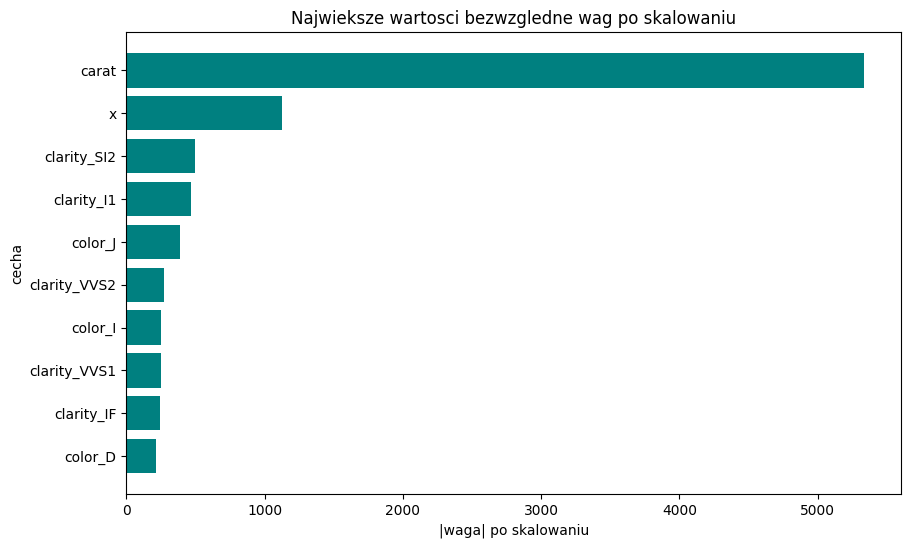

In [136]:
import pandas as pd

from helpers import build_weight_table
from plots import plot_top_weights


# W zadaniu 4.5 nie powtarzamy preprocessingu ani definicji modeli.
# Korzystamy z danych i klas przygotowanych juz w zadaniu 4.0.
# normal_model to model uczony na danych po standaryzacji.
scaled_weight_table = build_weight_table(
    X_train_encoded.columns.tolist(),
    normal_model.weights[1:],
    "weight_after_scaling",
)

print("Najwieksze wagi po skalowaniu:")
display(scaled_weight_table.head(10).round(4))

# Dla porownania uczymy dokladnie ten sam typ modelu, ale bez skalowania cech.
# Wtedy wspolczynniki pozostaja w oryginalnych jednostkach, np. karatach albo milimetrach.
normal_model_without_scaling = LinearRegressionNormalEquation()
normal_model_without_scaling.fit(X_train_array, y_train_array)

raw_weight_table = build_weight_table(
    X_train_encoded.columns.tolist(),
    normal_model_without_scaling.weights[1:],
    "weight_without_scaling",
)

print("Najwieksze wagi bez skalowania:")
display(raw_weight_table.head(10).round(4))


weight_comparison_45_df = scaled_weight_table[
    ["feature", "weight_after_scaling", "abs_weight_after_scaling"]
].merge(
    raw_weight_table[["feature", "weight_without_scaling", "abs_weight_without_scaling"]],
    on="feature",
    how="left",
)

print("Porownanie tych samych cech po skalowaniu i bez skalowania:")
display(weight_comparison_45_df.head(10).round(4))

carat_weight_without_scaling = raw_weight_table.loc[
    raw_weight_table["feature"] == "carat",
    "weight_without_scaling",
].iloc[0]
print("Waga cechy carat bez skalowania:", round(carat_weight_without_scaling, 4))


plot_top_weights(
    weight_comparison_45_df,
    "abs_weight_after_scaling",
    "Najwieksze wartosci bezwzgledne wag po skalowaniu",
    "|waga| po skalowaniu",
)


**Opis tabel wag po skalowaniu i bez skalowania oraz wykresu top wag**

Po skalowaniu najwiekszy wplyw na przewidywana cene ma cecha `carat`, a dalej widac istotny udzial cechy `x` oraz wybranych kategorii `clarity` i `color`. Taka interpretacja ma sens dziedzinowy, bo masa diamentu jest jednym z glownych czynnikow ceny, a jakosc i barwa rowniez silnie wplywaja na wycene.

Wykres najwiekszych wartosci bezwzglednych wag po skalowaniu pokazuje, ktore cechy maja najwiekszy wplyw na wynik po sprowadzeniu wszystkich zmiennych do wspolnej skali. Dzieki temu widac, ze `carat` zdecydowanie dominuje nad pozostalych cechami, a kolejne miejsca zajmuja juz zmienne o znacznie mniejszym wplywie.

W modelu bez skalowania mozna tez podac interpretacje pojedynczej wagi wprost po ludzku. Dla cechy `carat` wspolczynnik wynosi okolo `11280.78`, co oznacza, ze przy pozostalych cechach stalych wzrost masy diamentu o `1` karat zwieksza przewidywana cene srednio o okolo `11281` jednostek ceny. Taka interpretacja jest mozliwa dlatego, ze `carat` wystepuje tu w swojej naturalnej jednostce.


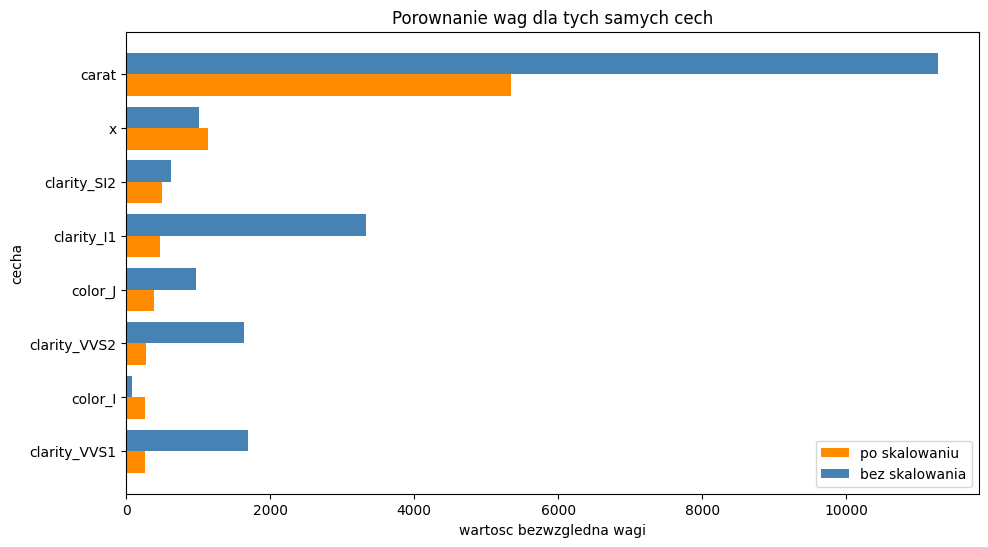

In [137]:
from plots import plot_weight_comparison


# Ten wykres zestawia dokladnie te same cechy dla obu wersji modelu.
# Dzieki temu widac, ze ranking i skala wag moga wygladac inaczej bez standaryzacji.
plot_weight_comparison(weight_comparison_45_df)


**Opis wykresu porownania wag przed i po skalowaniu**

Wykres porownujacy wagi przed i po skalowaniu pokazuje, ze sama kolejnosc cech i wysokosc slupkow moze sie zmieniac, gdy zmienne maja rozne jednostki i zakresy. To dlatego bez skalowania nie wolno bezrefleksyjnie uznawac, ze najwieksza liczbowo waga oznacza automatycznie najwazniejsza ceche.


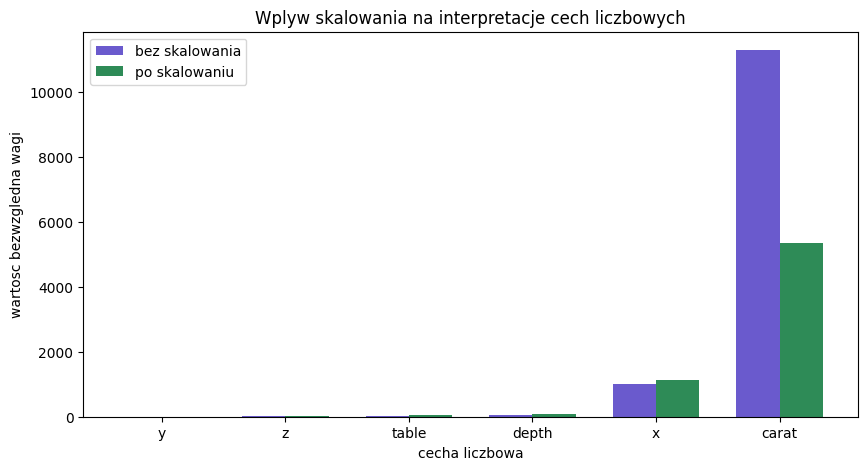

In [138]:
from plots import plot_numeric_weight_comparison


numeric_features = ["carat", "depth", "table", "x", "y", "z"]
numeric_comparison_df = weight_comparison_45_df[
    weight_comparison_45_df["feature"].isin(numeric_features)
].copy()


plot_numeric_weight_comparison(numeric_comparison_df)

**Opis wykresu dla cech liczbowych po skalowaniu**

Osobny wykres dla cech liczbowych `carat`, `depth`, `table`, `x`, `y` oraz `z` jeszcze wyrazniej pokazuje efekt skalowania. Po standaryzacji porownanie tych wag staje sie uczciwe, bo wzrost o `1` jednostke oznacza dla kazdej z nich wzrost o jedno odchylenie standardowe. Dlatego dopiero model po skalowaniu nadaje sie do sensownego porownania waznosci cech.


## Zadanie 5.0


W tej czesci pokazuje zjawisko `bias-variance tradeoff` oraz problem `Czarnego Labedzia` na prostym modelu regresji wielomianowej dla zaleznosci `carat -> price` w zbiorze `Diamonds`. Najpierw porownuje blad treningowy i testowy dla rosnacej zlozonosci modelu, a potem sprawdzam, jak zachowuja sie modele spokojne i przeuczone poza waskim zakresem danych treningowych.


In [139]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

import importlib
import plots
importlib.reload(plots)

from plots import plot_black_swan_comparison, plot_complexity_curves, plot_polynomial_fit_comparison

# Prosty model wielomianowy budowany na jednej cesze `carat`.
# Korzystamy ze standaryzacji po rozwinieciu cech, aby wysokie potegi nie psuly numeryki.
def build_polynomial_model(degree):
    return Pipeline(
        [
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("linear", LinearRegression()),
        ]
    )


# Do analizy bias-variance bierzemy tylko jedna ceche, bo wtedy wykresy sa czytelne.
X_train_bias = diamonds_train_df[["carat"]].copy()
y_train_bias = diamonds_train_df["price"].copy()
X_test_bias = diamonds_test_df[["carat"]].copy()
y_test_bias = diamonds_test_df["price"].copy()


# Sprawdzamy, jak zmieniaja sie bledy treningowe i testowe przy coraz bardziej zlozonym modelu.
complexity_results = []
for degree in range(1, 26):
    model = build_polynomial_model(degree)
    model.fit(X_train_bias, y_train_bias)

    train_predictions = model.predict(X_train_bias)
    test_predictions = model.predict(X_test_bias)

    complexity_results.append(
        {
            "degree": degree,
            "train_mse": mean_squared_error(y_train_bias, train_predictions),
            "test_mse": mean_squared_error(y_test_bias, test_predictions),
        }
    )

complexity_df = pd.DataFrame(complexity_results)
print("Tabela bledow dla kolejnych stopni wielomianu:")
display(complexity_df.round(2))

plot_complexity_curves(complexity_df)


ImportError: cannot import name 'plot_polynomial_fit_comparison' from 'plots' (c:\Users\Dudek\OneDrive\Pulpit\Repozytoria\Metody_systemowe_i_decyzyjne\lab2\plots.py)

**Opis wykresu krzywych zlozonosci**

Krzywe zlozonosci bardzo dobrze pokazuja klasyczny `bias-variance tradeoff`. Dla malych stopni wielomianu, szczegolnie `1` i `2`, zarowno blad treningowy, jak i testowy sa wyzsze. To jest strefa `high bias`, czyli `underfitting`: model jest za prosty, aby dobrze uchwycic zaleznosc miedzy `carat` i `price`.

W srodkowej czesci wykresu, w okolicach stopni od mniej wiecej `6` do `10`, blad testowy osiega najnizsze wartosci. To oznacza najlepszy kompromis miedzy elastycznoscia modelu a zdolnoscia do generalizacji. Model jest wtedy wystarczajaco bogaty, by uchwycic ksztalt zaleznosci, ale jeszcze nie dopasowuje sie agresywnie do szumu.

Dla bardzo wysokich stopni, szczegolnie w okolicach `15-25`, widac strefe `high variance`, czyli `overfitting`. Blad treningowy dalej maleje, bo model ma coraz wiecej swobody i moze coraz lepiej dopasowywac pojedyncze przypadki ze zbioru uczacego. Jednoczesnie blad testowy zaczyna rosnac, bo model zapamietuje lokalny szum i traci zdolnosc do poprawnej generalizacji na nowych danych.

Lewy panel pokazuje pelny zakres bledow, a prawy daje zoom tylko na male stopnie wielomianu. Dzieki temu da sie normalnie zobaczyc, jak zmieniaja sie krzywe w najwazniejszym fragmencie, zamiast patrzec na wykres zdominowany przez eksplozje bledu dla bardzo duzych stopni.


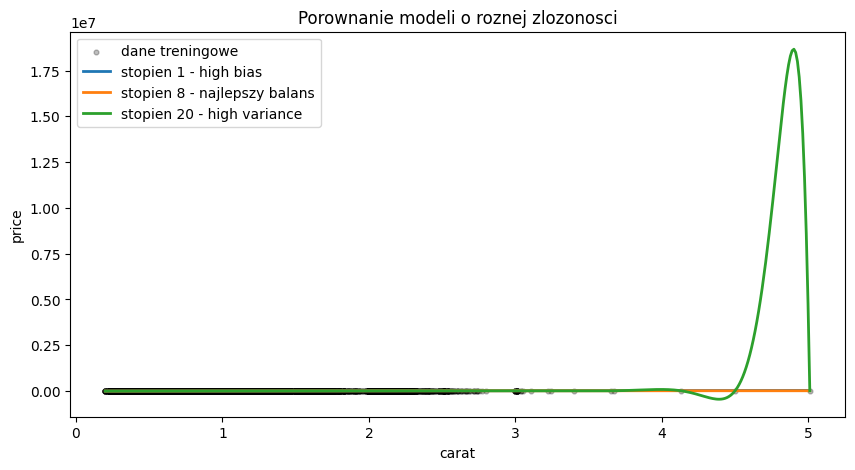

In [ ]:
# Wybieramy trzy modele do porownania:
# - prosty model o wysokim bias,
# - model o najlepszym balansie,
# - model bardzo zlozony, ktory zaczyna sie przeuczac.
best_degree = int(complexity_df.loc[complexity_df["test_mse"].idxmin(), "degree"])
high_bias_degree = 1
high_variance_degree = 20

carat_grid = pd.DataFrame(
    {"carat": pd.Series(
        np.linspace(X_train_bias["carat"].min(), X_train_bias["carat"].max(), 400)
    )}
)

# Lewy panel pokazuje tylko stopien 1 i stopien 8, aby skala osi Y byla czytelna.
fit_predictions_small = {}
for degree, label in [
    (high_bias_degree, "stopien 1 - high bias"),
    (best_degree, f"stopien {best_degree} - najlepszy balans"),
]:
    model = build_polynomial_model(degree)
    model.fit(X_train_bias, y_train_bias)
    fit_predictions_small[label] = model.predict(carat_grid)

# Prawy panel doklada stopien 20 i pokazuje, jak mocno przeuczony model psuje skale.
fit_predictions_full = {}
for degree, label in [
    (high_bias_degree, "stopien 1 - high bias"),
    (best_degree, f"stopien {best_degree} - najlepszy balans"),
    (high_variance_degree, "stopien 20 - high variance"),
]:
    model = build_polynomial_model(degree)
    model.fit(X_train_bias, y_train_bias)
    fit_predictions_full[label] = model.predict(carat_grid)

plot_polynomial_fit_comparison(
    X_train_bias["carat"],
    y_train_bias,
    carat_grid["carat"].to_numpy(),
    fit_predictions_small,
    fit_predictions_full,
)


**Opis wykresu porownania modeli o roznej zlozonosci**

W lewym panelu porownanie `stopnia 1` i `stopnia 8` jest czytelniejsze, bo skala osi `Y` nie zostaje rozciagnieta przez model przeuczony. Dzieki temu lepiej widac, jak bardzo model liniowy jest zbyt sztywny oraz jak spokojnie przebiega model o najlepszym balansie.

W prawym panelu zostal celowo dodany `stopien 20`, zeby pokazac koszt przeuczenia. Ten model jest tak czuly na drobne wahania, ze rozciaga skale wykresu i przez to utrudnia ocene pozostalych krzywych. Sam ten efekt jest juz dobrym sygnalem `high variance`.

To wlasnie koncepcyjnie wyjasnia, dlaczego wraz ze wzrostem skomplikowania algorytmu blad treningowy stale maleje, ale blad testowy po pewnym czasie rosnie: model zamiast uczyc sie prawidlowosci ogolnej, zaczyna zapamietywac szum i przypadkowe odchylenia obecne w treningu.


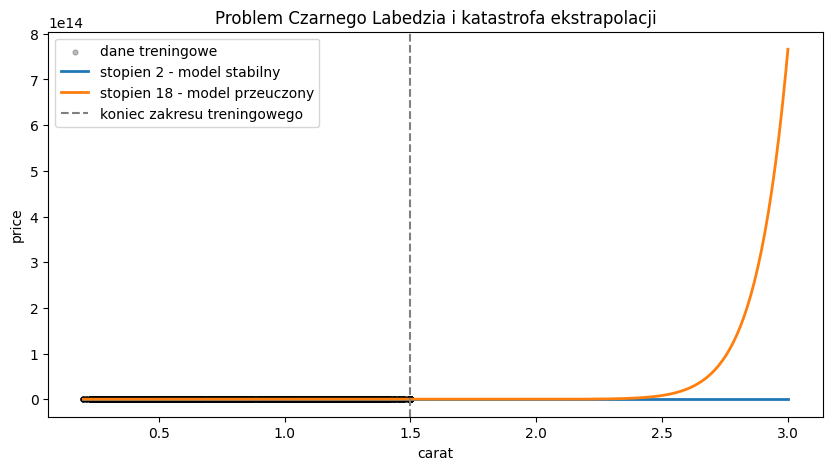

Predykcje poza zakresem treningowym:


,carat,prediction_degree_2,prediction_degree_18
0,2.0,16974.24,1.271762e+10
1,2.5,25498.03,8.156458e+12
2,3.0,35705.42,7.662232e+14


In [ ]:
# Eksperyment z "Czarnym Labedziem": uczymy modele tylko na waskim zakresie carat <= 1.5.
# Potem prosimy je o predykcje dla wiekszych diamentow, ktorych praktycznie nie widzialy na treningu.
black_swan_train_df = diamonds_train_df[diamonds_train_df["carat"] <= 1.5].copy()
X_train_black = black_swan_train_df[["carat"]].copy()
y_train_black = black_swan_train_df["price"].copy()

black_swan_grid = pd.DataFrame(
    {"carat": pd.Series(np.linspace(X_train_black["carat"].min(), 3.0, 400))}
)

stable_black_model = build_polynomial_model(2)
overfit_black_model = build_polynomial_model(18)

stable_black_model.fit(X_train_black, y_train_black)
overfit_black_model.fit(X_train_black, y_train_black)

black_swan_predictions = {
    "stopien 2 - model stabilny": stable_black_model.predict(black_swan_grid),
    "stopien 18 - model przeuczony": overfit_black_model.predict(black_swan_grid),
}

plot_black_swan_comparison(
    X_train_black["carat"],
    y_train_black,
    black_swan_grid["carat"].to_numpy(),
    black_swan_predictions,
    training_limit=1.5,
)

# Wypisujemy kilka konkretnych predykcji poza zakresem treningowym.
# To ulatwia pokazanie, jak szybko model przeuczony odlatuje przy ekstrapolacji.
black_swan_points = pd.DataFrame({"carat": [2.0, 2.5, 3.0]})
black_swan_df = pd.DataFrame(
    {
        "carat": black_swan_points["carat"],
        "prediction_degree_2": stable_black_model.predict(black_swan_points),
        "prediction_degree_18": overfit_black_model.predict(black_swan_points),
    }
)

print("Predykcje poza zakresem treningowym:")
display(black_swan_df.round(2))


**Opis wykresu Czarnego Labedzia**

Eksperyment z `Czarnym Labedziem` pokazuje jeszcze grozniejsza konsekwencje przeuczenia. Po ograniczeniu treningu do zakresu `carat <= 1.5` model stabilny stopnia `2` nadal ekstrapoluje w miare spokojnie, natomiast model stopnia `18` produkuje absurdalne wartosci poza znanym zakresem. To dlatego, ze wielomian wysokiego stopnia bardzo dokladnie dopasowuje sie do danych lokalnych, ale poza tym obszarem jego przebieg staje sie ekstremalnie niestabilny.

Lewy panel pokazuje pelna skale tej katastrofy, a prawy przybliza sensowny zakres wartosci. Bez takiego zoomu ogromne wartosci modelu przeuczonego rozciagaja os `Y` tak mocno, ze trudno zobaczyc, jak zachowuje sie model stabilny i co dzieje sie tuz za granica danych treningowych.

Tabela predykcji poza zakresem treningowym pokazuje to juz bezposrednio liczbowo. Dla `3.0` karatow model stabilny przewiduje wartosc duza, ale jeszcze mieszczaca sie w sensownej skali, natomiast model przeuczony daje katastrofalnie zawyzona predykcje. To jest wlasnie praktyczny sens problemu `Czarnego Labedzia`: rzadkie lub nowe przypadki spoza waskiego zakresu treningowego potrafia calkowicie zlamac model przeuczony.

Modele uodparniamy na takie anomalie przez ograniczanie ich zlozonosci. Dla drzew decyzyjnych mozna to robic na przyklad przez ograniczenie `max_depth` albo przycinanie drzewa. Dla modeli regresyjnych klasyczna technika to `Ridge`, czyli regularyzacja `L2`, ktora karze zbyt duze wspolczynniki i stabilizuje model.
